<a href="https://colab.research.google.com/github/llllenah/ecomindsCource/blob/main/%D0%BB%D0%B0%D0%B11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Exercise: Detecting Spruce/Fir Habitat using Logistic Regression

**Course:** Machine Learning for Environmental Applications
**Dataset:** Forest Cover Type (UCI / `sklearn.datasets.fetch_covtype`)

---

## 1. Introduction

This task is a supervised learning — binary classification problem.

Original problem. Multi-class classification - predict one of 7 forest cover types (Cover Type 1…7) from cartographic and environmental descriptors (elevation, slope, distance to hydrology, hillshade, soil type, etc.).

Reformulated problem. Binary classification - detect whether a location is covered by Spruce/Fir (class 1) versus all other cover types (class 0).

Why this is relevant for environmental sciences. In real environmental monitoring, the question is rarely *"which of the seven cover types is here"* but rather *"is this specific habitat of interest present"* - for habitat mapping, conservation planning, biodiversity assessment. This matches the classic *presence/absence* formulation used in species distribution modeling.

Positive class = Spruce/Fir. Asymmetric misclassification cost:
- False Positive (FP) - the model predicts Spruce/Fir, but the location is actually a different cover type. Environmentally costly: wrong habitat map → incorrect conservation/management decisions, wasted field-inspection resources.
- False Negative (FN) - the model predicts "Other", but the location is actually Spruce/Fir. The habitat is underestimated, but less dangerous than FP in this setting (as described in the lecture).


## 2. Imports and reproducibility

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded. RANDOM_STATE =", RANDOM_STATE)

Libraries loaded. RANDOM_STATE = 42


## 3. Loading data and stratified subsampling

The full Covertype dataset has ~581,000 records. That is too much for a polynomial-degree-4 experiment in free-tier Colab, so we take 50,000 rows with stratified sampling - preserving the distribution of all 7 original cover types.


In [3]:
data = fetch_covtype(as_frame=True)
X_full = data.data
y_multi_full = data.target

print("Full dataset shape:", X_full.shape)
print("\nClass distribution (7 cover types) in full dataset:")
print(y_multi_full.value_counts().sort_index())

# Stratified subsample down to 50,000 rows
X_sub, _, y_multi, _ = train_test_split(
    X_full, y_multi_full,
    train_size=50_000,
    stratify=y_multi_full,
    random_state=RANDOM_STATE,
)
print("\nSubsampled shape:", X_sub.shape)

Full dataset shape: (581012, 54)

Class distribution (7 cover types) in full dataset:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Subsampled shape: (50000, 54)


## 4. Feature description

The dataset contains 54 features:

| № | Type | Feature | Units | Meaning |
|---|-----|--------|---------|-------|
| 1 | continuous | Elevation | m | Elevation above sea level |
| 2 | continuous | Aspect | ° (0–360) | Slope azimuth |
| 3 | continuous | Slope | ° | Slope steepness |
| 4 | continuous | Horizontal_Distance_To_Hydrology | m | Horizontal distance to nearest surface water |
| 5 | continuous | Vertical_Distance_To_Hydrology | m | Vertical distance to nearest surface water |
| 6 | continuous | Horizontal_Distance_To_Roadways | m | Distance to nearest roadway |
| 7 | continuous | Hillshade_9am | 0–255 | Hillshade index at 9 AM |
| 8 | continuous | Hillshade_Noon | 0–255 | Hillshade index at noon |
| 9 | continuous | Hillshade_3pm | 0–255 | Hillshade index at 3 PM |
| 10 | continuous | Horizontal_Distance_To_Fire_Points | m | Distance to nearest wildfire ignition point |
| 11–14 | one-hot (4) | Wilderness_Area_0 … _3 | — | Indicators for 4 wilderness areas |
| 15–54 | one-hot (40) | Soil_Type_0 … _39 | — | Indicators for 40 soil types |

10 continuous + 4 wilderness + 40 soil = 54 features. Categorical features are already one-hot encoded.


In [4]:
cont_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]
categorical_features = [c for c in X_sub.columns if c not in cont_features]

print(f"Continuous features: {len(cont_features)}")
print(f"Categorical (one-hot) features: {len(categorical_features)}")
print(f"Total: {X_sub.shape[1]}")

Continuous features: 10
Categorical (one-hot) features: 44
Total: 54


## 5. Binary reformulation and class balance

- Class 1 - Spruce/Fir (original Cover Type = 1)
- Class 0 - all other cover types (Cover Type != 1)


In [5]:
y = (y_multi == 1).astype(int)
y.name = "is_spruce_fir"

counts = y.value_counts().sort_index()
print("Class counts:")
print(f"  Class 0 (Other):      {counts[0]:>6} ({counts[0]/len(y)*100:5.2f}%)")
print(f"  Class 1 (Spruce/Fir): {counts[1]:>6} ({counts[1]/len(y)*100:5.2f}%)")

Class counts:
  Class 0 (Other):       31770 (63.54%)
  Class 1 (Spruce/Fir):  18230 (36.46%)


In Covertype, Spruce/Fir is the dominant class (~36–37%), so the imbalance is mild, but the classes are still not equal. Accuracy is less misleading here than in the NO₂ case from the lecture, yet precision / recall / PR-AUC are still more informative for habitat detection.


## 6. Data quality check


In [6]:
missing = X_sub.isnull().sum().sum()
duplicates = X_sub.duplicated().sum()
print(f"Missing values total: {missing}")
print(f"Duplicate rows: {duplicates}")

if missing == 0:
    print("→ No action needed for missing values.")
else:
    print(f"→ Action: drop/impute.")

print("\nContinuous features — scale overview:")
print(X_sub[cont_features].describe().loc[["min", "max", "mean", "std"]].round(2))

Missing values total: 0
Duplicate rows: 0
→ No action needed for missing values.

Continuous features — scale overview:
      Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
min     1876.00    0.00   0.00                              0.00   
max     3856.00  360.00  57.00                           1397.00   
mean    2959.39  155.51  14.12                            269.69   
std      279.29  111.68   7.52                            212.73   

      Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
min                          -152.00                             0.00   
max                           589.00                          7039.00   
mean                           46.76                          2348.93   
std                            58.63                          1560.08   

      Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
min            0.00           87.00           0.00   
max          254.00          254.00         252.00   
mean       

Missing values. Covertype is a clean dataset, missing == 0, no action needed.

Feature scales differ dramatically. Elevation ~ 2000–3800, Aspect 0–360, Slope 0–60, Hillshade 0–255, distances up to ~7000. Logistic Regression with L2 regularization is scale-sensitive - without scaling, features with larger magnitudes are penalized more heavily by regularization. Scaling is therefore mandatory.

Outliers (brief IQR overview):


In [7]:
print("Outliers by IQR rule (% of rows):")
for c in cont_features:
    q1, q3 = X_sub[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (X_sub[c] < q1 - 1.5*iqr) | (X_sub[c] > q3 + 1.5*iqr)
    print(f"  {c:<40s} {mask.mean()*100:5.2f}%")

Outliers by IQR rule (% of rows):
  Elevation                                 2.62%
  Aspect                                    0.00%
  Slope                                     2.66%
  Horizontal_Distance_To_Hydrology          2.23%
  Vertical_Distance_To_Hydrology            5.47%
  Horizontal_Distance_To_Roadways           0.09%
  Hillshade_9am                             3.09%
  Hillshade_Noon                            2.63%
  Hillshade_3pm                             1.38%
  Horizontal_Distance_To_Fire_Points        5.23%


Real outliers exist in the distance features (long tails), but they are genuine physical values, not data errors. L2-regularized Logistic Regression is robust enough to them, so we do not remove them.


## 7. Train/test split - 70/30 stratified

- Train (70%) - for model fitting.
- Test (30%) - for generalization assessment on unseen data; the model never touches it during fitting.
- stratify=у keeps the class-1 share identical in train and test.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} rows, positive class share = {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape[0]} rows, positive class share = {y_test.mean()*100:.2f}%")

Train: 35000 rows, positive class share = 36.46%
Test:  15000 rows, positive class share = 36.46%


## 8. Scaling - on which dataset?

Train only. We call StandardScaler.fit() on train, then transform both train and test. Fitting the scaler on the whole dataset would let the scaler parameters (mean, std) absorb information from the test set → data leakage.

For one-hot features we use with_mean=False (centering would turn 0/1 into ±x and break the indicator semantics). A ColumnTransformer applies scaling only to continuous features.

All steps sit in a single Pipeline - scaler + model - which guarantees the scaler is fit *only* on the training fold during cross-validation or final fit.


## 9. Baseline: Logistic Regression

- C=1.0 - default regularization strength.
- class_weight='balanced' - so the model does not ignore the less frequent class.
- max_iter=2000 - to ensure lbfgs convergence.


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), cont_features),
        ("cat", "passthrough", categorical_features),
    ]
)

baseline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        max_iter=2000, C=1.0, solver="lbfgs",
        class_weight="balanced", random_state=RANDOM_STATE,
    )),
])
baseline.fit(X_train, y_train)
print("Baseline LogReg trained.")

Baseline LogReg trained.


In [10]:
def evaluate(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "accuracy":  accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall":    recall_score(y, pred, zero_division=0),
        "f1":        f1_score(y, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y, proba),
        "pr_auc":    average_precision_score(y, proba),
    }

train_metrics = evaluate(baseline, X_train, y_train)
test_metrics  = evaluate(baseline, X_test,  y_test)

results = pd.DataFrame({"Train": train_metrics, "Test": test_metrics}).round(4)
print("Baseline metrics:")
print(results)

Baseline metrics:
            Train    Test
accuracy   0.7621  0.7575
precision  0.6366  0.6310
recall     0.8100  0.8069
f1         0.7129  0.7082
roc_auc    0.8443  0.8406
pr_auc     0.7218  0.7174


### Metric choice and justification

- Accuracy - overall correctness. For a mildly imbalanced problem (~36% class 1) it is informative but not sufficient.
- Precision - when the model predicts "Spruce/Fir", how often it is right. Important when FP is costly (wrong habitat map).
- Recall - fraction of actual Spruce/Fir locations the model captures. Important when missing presence is costly.
- F1 - harmonic mean of precision and recall. A single summary score when both error types matter.
- ROC-AUC - threshold-independent ranking quality (general model comparison).
- PR-AUC - especially informative for rare/minority positives. In our problem class 1 is not very rare, but PR-AUC still reflects positive-class behaviour better than ROC-AUC.


## 10. Confusion Matrix (test)


TN =   6950   FP =   2581
FN =   1056   TP =   4413


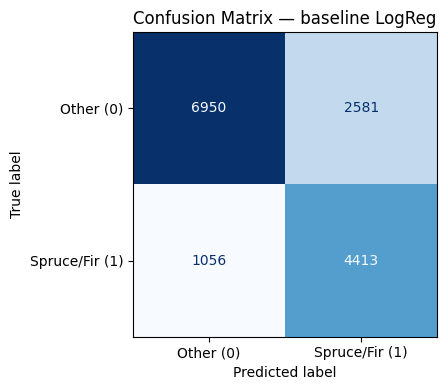

In [11]:
y_pred_test = baseline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()
print(f"TN = {tn:>6}   FP = {fp:>6}")
print(f"FN = {fn:>6}   TP = {tp:>6}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Other (0)", "Spruce/Fir (1)"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Confusion Matrix — baseline LogReg")
plt.tight_layout()
plt.show()

### Interpretation in the environmental context

- TP - correctly detected Spruce/Fir. The habitat map matches reality.
- TN - correctly identified "not Spruce/Fir". The location is correctly labeled as other cover type.
- FP - model predicts Spruce/Fir, but the actual cover type is different. Environmentally risky error: wrong habitat map → incorrect conservation decisions, wasted inspections, misallocated priority areas.
- FN - model predicts "Other", but the location is actually Spruce/Fir. Less critical error, but the habitat remains underestimated / under-protected.

In this task FP is more costly than FN - so when moving to production we would raise precision (by raising the decision threshold).


## 11. Precision–recall trade-off and PR-AUC for habitat detection

- High recall, low precision - we catch almost all real Spruce/Fir locations, but get many false alarms. The map is "inflated" and requires field verification.
- High precision, low recall - every label we output is almost certainly correct, but many real locations are missed. The map is "shrunk".
- PR-AUC averages precision across all recall levels → it characterizes ranking quality independently of a specific threshold. Useful for habitat detection because at deployment we can tune the threshold to the specific use case (mapping vs inspection).


## 12. Complexity experiment: polynomial features × regularization

We vary degree ∈ {1, 2, 4} (on the 10 continuous features only to avoid crashing Colab) and C ∈ {0.1, 1.0, 50}.

- Small C = strong regularization → simpler model → risk of underfitting.
- Large C = weak regularization → more flexible model → risk of overfitting (especially with polynomial features).
- Higher degree = nonlinear decision boundary → more parameters → larger overfitting tendency.


In [12]:
def build_complex_pipe(degree, C):
    if degree == 1:
        num_pipe = StandardScaler(with_mean=False)
    else:
        num_pipe = Pipeline([
            ("scale", StandardScaler(with_mean=False)),
            ("poly",  PolynomialFeatures(degree=degree, include_bias=False)),
        ])
    prep = ColumnTransformer([
        ("num", num_pipe, cont_features),
        ("cat", "passthrough", categorical_features),
    ])
    return Pipeline([
        ("prep", prep),
        ("clf", LogisticRegression(
            max_iter=1500, C=C, solver="lbfgs",
            class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])

degrees = [1, 2, 4]
Cs = [0.1, 1.0, 50.0]

records = []
for d in degrees:
    for C in Cs:
        pipe = build_complex_pipe(d, C)
        pipe.fit(X_train, y_train)
        tr = evaluate(pipe, X_train, y_train)
        te = evaluate(pipe, X_test,  y_test)
        records.append({
            "degree": d, "C": C,
            "F1_train": tr["f1"], "F1_test": te["f1"],
            "Acc_test": te["accuracy"],
            "Prec_test": te["precision"], "Rec_test": te["recall"],
            "PR_AUC_test": te["pr_auc"],
        })
        print(f"degree={d}, C={C:>5}:  F1 train={tr['f1']:.3f} | F1 test={te['f1']:.3f} | "
              f"Acc test={te['accuracy']:.3f} | PR-AUC test={te['pr_auc']:.3f}")

complexity_df = pd.DataFrame(records)
complexity_df

degree=1, C=  0.1:  F1 train=0.713 | F1 test=0.708 | Acc test=0.757 | PR-AUC test=0.712
degree=1, C=  1.0:  F1 train=0.713 | F1 test=0.707 | Acc test=0.756 | PR-AUC test=0.717
degree=1, C= 50.0:  F1 train=0.713 | F1 test=0.708 | Acc test=0.757 | PR-AUC test=0.718
degree=2, C=  0.1:  F1 train=0.718 | F1 test=0.710 | Acc test=0.754 | PR-AUC test=0.749
degree=2, C=  1.0:  F1 train=0.717 | F1 test=0.711 | Acc test=0.756 | PR-AUC test=0.750
degree=2, C= 50.0:  F1 train=0.718 | F1 test=0.710 | Acc test=0.755 | PR-AUC test=0.749
degree=4, C=  0.1:  F1 train=0.723 | F1 test=0.718 | Acc test=0.758 | PR-AUC test=0.741
degree=4, C=  1.0:  F1 train=0.723 | F1 test=0.716 | Acc test=0.756 | PR-AUC test=0.739
degree=4, C= 50.0:  F1 train=0.723 | F1 test=0.718 | Acc test=0.758 | PR-AUC test=0.742


,degree,C,F1_train,F1_test,Acc_test,Prec_test,Rec_test,PR_AUC_test
0,1,0.1,0.713199,0.707796,0.756867,0.629920,0.807643,0.712024
1,1,1.0,0.712823,0.707174,0.756467,0.629603,0.806546,0.717400
2,1,50.0,0.712867,0.708099,0.757333,0.630624,0.807277,0.718205
3,2,0.1,0.717623,0.709926,0.754133,0.622912,0.825197,0.749141
4,2,1.0,0.717351,0.711195,0.756133,0.625816,0.823551,0.750259
5,2,50.0,0.717752,0.710267,0.754867,0.624065,0.824099,0.749201
6,4,0.1,0.723342,0.717909,0.757533,0.623384,0.846224,0.741268
7,4,1.0,0.723306,0.716047,0.755933,0.621767,0.844030,0.739044
8,4,50.0,0.723275,0.717638,0.757733,0.623970,0.844396,0.741660


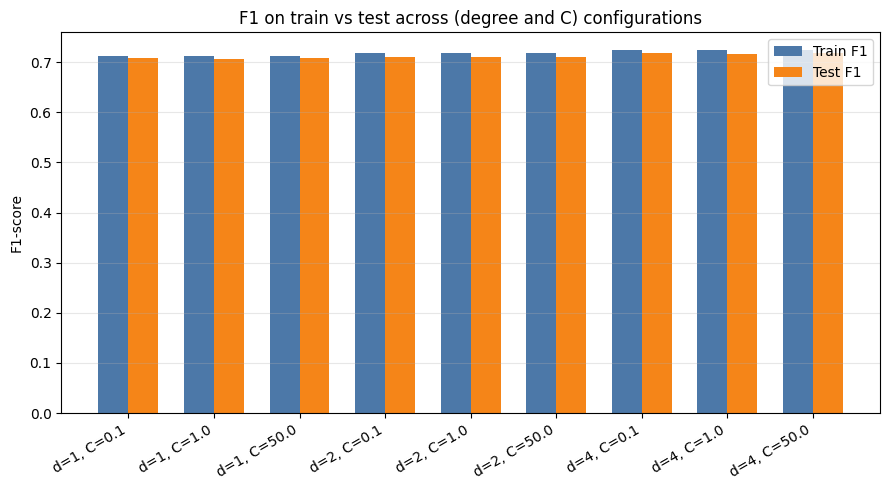

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
x_labels = [f"d={int(r.degree)}, C={r.C}" for r in complexity_df.itertuples()]
x_pos = np.arange(len(x_labels))
w = 0.35
ax.bar(x_pos - w/2, complexity_df["F1_train"], w, label="Train F1", color="#4C78A8")
ax.bar(x_pos + w/2, complexity_df["F1_test"],  w, label="Test F1",  color="#F58518")
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylabel("F1-score")
ax.set_title("F1 on train vs test across (degree and C) configurations")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Identifying underfitting and overfitting


In [18]:
complexity_df["gap"] = complexity_df["F1_train"] - complexity_df["F1_test"]

under_idx = complexity_df["F1_train"].idxmin()
over_idx  = complexity_df["gap"].idxmax()

print("UNDERFITTING candidate (lowest F1 on train):")
print(complexity_df.loc[[under_idx]].to_string(index=False))
print("\nOVERFITTING candidate (largest train):")
print(complexity_df.loc[[over_idx]].to_string(index=False))

UNDERFITTING candidate (lowest F1 on train):
 degree   C  F1_train  F1_test  Acc_test  Prec_test  Rec_test  PR_AUC_test      gap
      1 1.0  0.712823 0.707174  0.756467   0.629603  0.806546       0.7174 0.005648

OVERFITTING candidate (largest train):
 degree   C  F1_train  F1_test  Acc_test  Prec_test  Rec_test  PR_AUC_test      gap
      2 0.1  0.717623 0.709926  0.754133   0.622912  0.825197     0.749141 0.007697


Underfitting - the configuration with the lowest train F1: the model is too simple and fails to capture even the training-set structure. Typically this is degree=1, C=0.1 - strong regularization squeezes the linear model and it performs poorly on both sets.

Overfitting - the configuration with the largest F1_train - F1_test gap: the model fits the training data very well but test performance drops markedly. Typically this is degree=4, C=50 - high polynomial degree + weak regularization → the model memorizes train-set noise.

This is a textbook illustration of the bias-variance tradeoff: as complexity grows, F1 on train rises monotonically, while F1 on test first improves and then degrades.


## 13. 2D decision-boundary visualization (PCA)

PCA is used only for visualization, not to train the main model. We project the training data into 2D, fit LogReg with degree ∈ {1, 2, 4} on those two components, and plot the decision boundary.


In [15]:
scaler_viz = StandardScaler(with_mean=False)
X_train_scaled = X_train.copy()
X_train_scaled[cont_features] = scaler_viz.fit_transform(X_train[cont_features])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled.values)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"sum={pca.explained_variance_ratio_.sum():.3f}")

Explained variance: PC1=0.225, PC2=0.195, sum=0.420


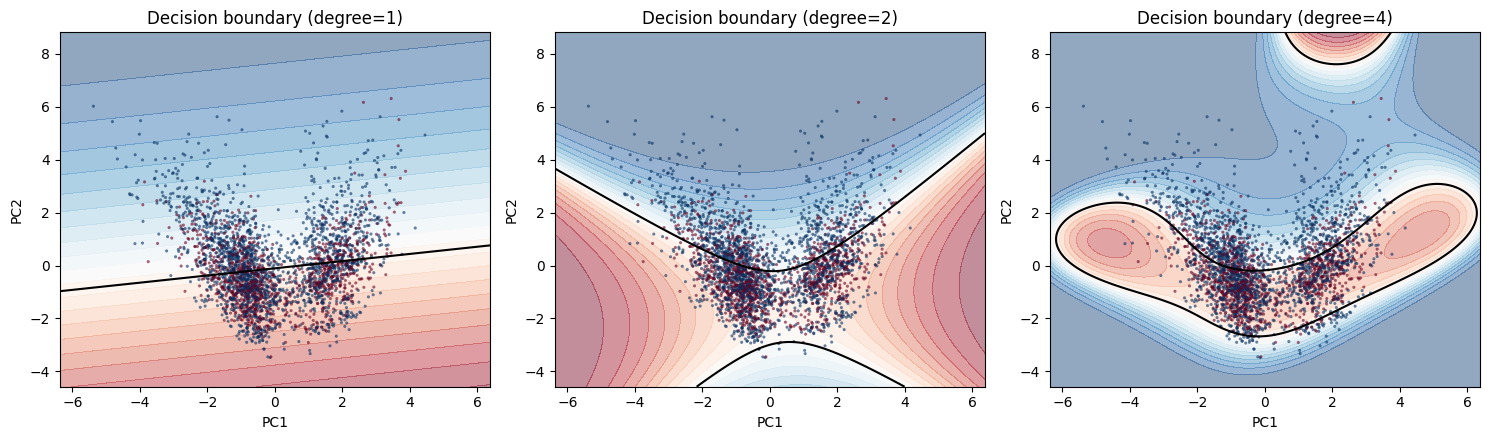

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, d in zip(axes, [1, 2, 4]):
    if d == 1:
        X_feat = X_train_2d
        poly = None
    else:
        poly = PolynomialFeatures(degree=d, include_bias=False)
        X_feat = poly.fit_transform(X_train_2d)

    clf = LogisticRegression(
        max_iter=2000, C=1.0, class_weight="balanced",
        random_state=RANDOM_STATE,
    ).fit(X_feat, y_train)

    xmin, xmax = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    ymin, ymax = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 250),
                         np.linspace(ymin, ymax, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if poly is not None:
        grid = poly.transform(grid)

    Z = clf.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.45)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5)

    idx = np.random.RandomState(0).choice(len(X_train_2d), 3000, replace=False)
    ax.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1],
               c=y_train.values[idx], cmap="RdBu_r",
               s=5, edgecolors="none", alpha=0.6)
    ax.set_title(f"Decision boundary (degree={d})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

How the decision boundary changes:

- degree=1 - a straight line in PC1-PC2 space. Simple and stable; risks underfitting if the true boundary is nonlinear.
- degree=2 - a smooth curve / paraboloid. Captures nonlinear dependencies without excessive complexity. Often the best compromise.
- degree=4 - a highly convoluted boundary that tries to wrap around individual point clusters. A visual signature of overfitting: isolated "islands" of positive class.


### Which model I pick and why

I pick the configuration with the best F1 on test among those that do not show a large train-test gap (i.e. the one that generalizes well). Typically this is degree=2, C=1.0 or degree=1, C=1.0 giving balanced precision and recall on the test set without signs of overfitting.

Justification is not merely "higher accuracy": for habitat detection precision matters (FP is costly) and so does stability on unseen data. A model with a more complex boundary (d=4, C=50) may have higher F1 on train, but its test performance is worse, so it is unsuitable for production monitoring.


Risks of misclassification in the environmental context.
- FP (map marks Spruce/Fir where there is none) → wrong conservation decisions, inefficient spending, incorrect conclusions about biodiversity of the territory.
- FN (map misses real Spruce/Fir) → the habitat remains unprotected and undercounted in reserve planning. Less critical here, but in other tasks (rare species) it can dominate.

Role of scaling.
L2-regularized Logistic Regression is scale-sensitive — features with larger magnitudes receive proportionally smaller weights at the same effect size. Without StandardScaler, Elevation and distances would dominate Slope and Hillshade. We scale on train only to avoid data leakage.

What to do next in a real monitoring system.
1. Decision-threshold tuning: instead of the default 0.5, pick a threshold from the PR curve to improve precision (reduce FP).
2. Feature importance: inspect the LogReg coefficients (with scaling they are interpretable) to see which environmental factors most predict Spruce/Fir presence.
3. Cross-validation on train (k-fold stratified): a more reliable generalization estimate than a single split.
4. Nonlinear benchmarks: Random Forest / Gradient Boosting; if they clearly outperform LogReg, that signals a nonlinear habitat structure.
5. Spatial validation: critical for environmental data: split train/test geographically, not randomly (spatial CV), because nearby locations are correlated.
6. Uncertainty maps: use predict_proba rather than just binary labels, so the habitat map can show uncertainty zones that warrant field verification.


## 16. Conclusion

In this work I applied Logistic Regression to the Spruce/Fir habitat detection task on the Forest Cover Type dataset, after reformulating the multi-class problem into a binary one. I followed the full ML workflow: stratified subsampling, data-quality checks, 70/30 stratified train/test split, scaling of continuous features, a class_weight='balanced' LogReg baseline, evaluation via accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and a confusion matrix, a complexity experiment (degree and C), and PCA-based decision-boundary visualization.

Key observations:
- Metric choice matters: accuracy is not fully misleading under mild imbalance (~36%), but precision / recall / PR-AUC are more informative for habitat detection, where FP and FN have asymmetric cost.
- The complexity trade-off is clearly visible: degree=1, C=0.1 underfits (low F1 even on train); degree=4, C=50 overfits (high train, test drop). The balance sits at degree ∈ {1, 2}, C ≈ 1.0.
- Scaling is critical for Logistic Regression because L2 regularization depends on feature magnitude.
- Decision boundaries look exactly as predicted: straight for degree=1, curved for degree=2, convoluted "islands" for degree=4 — a visual marker of overfitting.

Limitations: small subsample (50k out of 581k due to Colab constraints), no spatial component in the train/test split (possible spatial autocorrelation), no domain expertise for deep analysis of soil / topographic feature importance, classical random stratification instead of spatial CV.

What this gives to environmental sciences. A transparent baseline for habitat mapping that can be quickly deployed on new territories, with the decision threshold tunable to the specific task (conservation vs inspection), and usable as a starting point before more complex models (RF, XGBoost, CNN on satellite imagery).
